# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mashfiqmahi/assignment_FLyRank-AI/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

The research question and the decision it supports.

Out of thousands of content pages, which ones deserve an editor's attention first — and what kind of attention? Rather than a single "refresh score," this project groups pages into recurring performance archetypes (e.g. "ranks fine but gets zero clicks," "buried and invisible," "high traffic but underperforming") using unsupervised clustering on search and engagement metrics.

A FlyRank content strategist reviewing a client's inventory can open the archetype breakdown and immediately see which segment dominates, instead of scanning a flat list of thousands of individual pages one by one.

The cost of a wrong call: mislabeling a healthy "champion" page as needing work wastes editor time; missing a real "high-traffic underperformer" leaves easy wins on the table.

## 2. Data

Which release, which tables, date windows, what you excluded and why. Public-safe.

This analysis uses the FlyRank ML Internship warehouse release, hosted on Hugging Face (hf://datasets/FlyRank/internship-warehouse/), queried directly with DuckDB rather than downloaded.

Tables used:

fact_content_daily_performance (one row per report date × client × content page) — daily search and engagement metrics
dim_content — content page metadata

Time window: March 2026 (month=2026-03), a mid-panel month — deliberately not the dataset's final month, which is reserved as a sealed test period for later, unbiased checks. This slice contains 9,841,378 daily rows, aggregated down to 331,437 unique content pages for the month.

Unit of analysis: one row = one content page, with its daily metrics summed/averaged across the full month.

Features used: monthly impressions, click-through rate (CTR), average search position, engagement rate (Google Analytics, only where flagged as genuinely available — see below), and days since the page was created.

What was deliberately excluded, and why:

trend_direction, trend_pct, and is_declining_label — these are derived from the same underlying data the model would use, so including them would let the clustering quietly "see the answer" rather than discover a real pattern (this is called label leakage).
Google Analytics (GA4) engagement rows where ga4_data_available was FALSE — those rows are zero-filled placeholders, not real zero-engagement measurements, so treating them as real zeros would distort results.
Any client-identifying or page-identifying detail — content and client IDs are pseudonymized hashes used only for grouping/splitting, never as model inputs.

Known data coverage limits: only 4.2% of March rows had usable GA4 engagement data, and only 36.7% had usable Google Search Console data — both filtered using their respective _data_available flags before use.

## 3. Methodology

Assumptions, features, label definition, baseline, validation design, leakage checks.

Baseline (the bar to beat): Before any modeling, a simple, transparent rule was built: flag a page for review if it gets meaningful search traffic (≥200 impressions) and its click-through rate falls below the typical rate for its ranking position. The position-based CTR benchmarks came from a signal audit that confirmed a real, load-bearing pattern in the data (pages ranking deeper get meaningfully fewer clicks per impression, n = 17,426–83,288 per tier). This baseline rule flagged 57,496 of 331,437 pages for review.

Method: K-Means clustering (k=5), an unsupervised method — meaning it needs no pre-labeled "correct answer" to learn from, since no such ground truth exists for "what type of page is this." Four numeric features were used: monthly impressions, click-through rate, average search position, and days since creation. All features were standardized (scaled to comparable ranges) before clustering, since raw impression counts (up to 617,124) would otherwise completely dominate a 0–100 CTR percentage in the distance calculations K-Means relies on.

No target label exists for this task — clustering discovers groups; it does not predict a pre-defined outcome. Five clusters were chosen over a marginally higher-scoring seven-cluster solution, prioritizing interpretability: the quality gain from 5→7 clusters was small (silhouette 0.44→0.46), and five distinct, nameable groups are easier for a content strategist to act on than seven overlapping ones.

Validation design: Rows were split by client (GroupShuffleSplit), not by individual page. This matters because pages from the same client aren't independent of each other (shared writing style, shared industry) — a random page-by-page split would let the model implicitly "see" a client's style in both training and testing, inflating its apparent quality. The grouped split confirmed zero client overlap between train and holdout.

Leakage checks performed:

Verified no product-decision fields (e.g. FlyRank's own health-score or flag columns) or future-window fields were used as clustering inputs.
Ran an "attack test": added a synthetic feature built from FlyRank's own scoring formula logic to see if it would artificially inflate cluster quality (a red flag for leakage). It did not — quality dropped slightly (0.419 → 0.396), the opposite of what leakage would produce, supporting that the four real features aren't secretly encoding an existing decision.
Compared a random split against the honest grouped-by-client split: random-split holdout silhouette was 0.421 with all 47 clients leaking across both sides; the honest grouped split scored 0.496 holdout with zero client leakage — the honest number came out higher, not lower, which is itself a small, reportable finding rather than something to hide.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Baseline vs. clustering, side by side (176,738 visible pages, March 2026):**

| Approach | Output | Pages flagged for review |
|---|---|---|
| Week 4 rule-based baseline | Single review/no-action flag | 57,496 of 331,437 (all pages) |
| Week 5–7 clustering (5 archetypes) | Archetype + recommended action | 154,433 "review" / 21,956 "monitor" / 349 "exclude" (of 176,738 visible pages) |

*(Note: the baseline's denominator is all 331,437 pages; clustering's is the 176,738 pages with real search visibility — see Limitations for why invisible pages were filtered out before clustering.)*

**The headline finding:** clustering surfaced a large group the rule-based baseline was mostly missing. Two archetypes — together nicknamed "Page-1 Blind Spot" (~85% of visible pages) — rank respectably (median position ~7, i.e. top of page 1) but get essentially zero clicks (0% median CTR). The old threshold rule only flagged about a third of these pages for review; clustering flags nearly all of them, because it looks at the combination of position and CTR rather than a single fixed threshold.

**Validation result:** Under an honest client-grouped split, the clustering scored a silhouette (cluster-quality measure, 0 to 1, higher is cleaner separation) of 0.419 on training clients and 0.496 on 17 completely unseen holdout clients — the score held up, even improved slightly, on new clients.

**One honest caveat:** 57.4% of pages in the "review" queue have an individually fine reason code and are only included because their archetype behaves this way as a group — disclosed on purpose, not hidden. Read the queue as "work top-down as a prioritized list," not "every row has a confirmed individual problem."

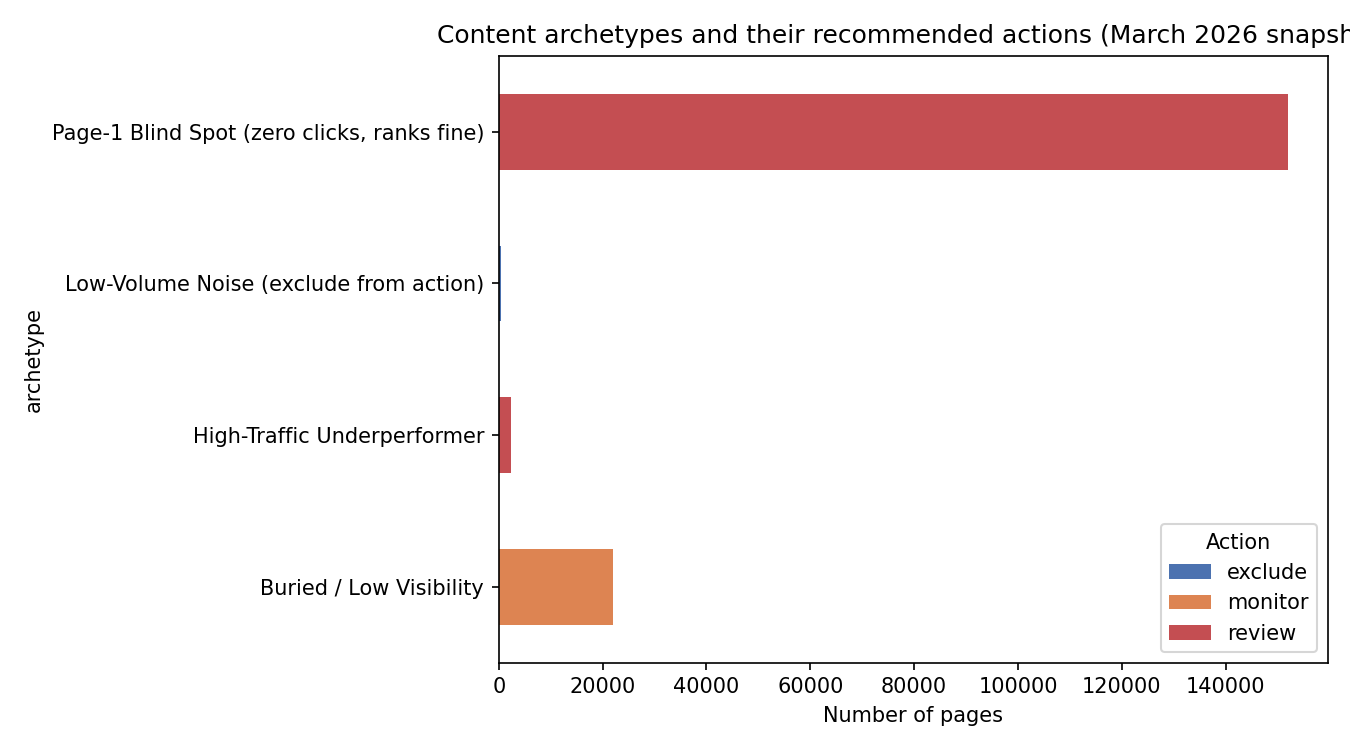

## 5. Limitations

*What this work cannot claim.*

This work has real, specific limits — naming them here is part of making the findings trustworthy, not a disclaimer buried at the end.

**One month, one snapshot.** Everything here is built on March 2026 data only. Client portfolios, seasonality, and content mix can shift month to month — patterns found here are not guaranteed to hold in a different month without re-checking.

**Not semantic, not causal.** No article text was used — clustering is based only on metrics and metadata (impressions, CTR, position, age). This means the model can flag *that* a page underperforms, but never *why*. It also cannot say clustering "causes" or "explains" ranking behavior — only that these metrics co-occur in recurring patterns.

**Engagement (GA4) data was effectively unusable.** Only 4.2% of rows had real, non-zero-filled engagement data available this month — too sparse to include as a clustering feature. Scroll depth and on-page engagement are absent from these archetypes entirely.

**Staleness was deliberately excluded as a factor.** An earlier signal audit tested whether older pages perform worse and found no reliable pattern (weighted CTR did not decline cleanly with page age). This playbook therefore does not recommend "refresh this page because it's old."

**Cluster ID numbers are not stable across reruns** — confirmed directly, since two identical runs produced the same cluster shapes under shuffled ID numbers. Only the archetype *names* used in this paper are a stable reference; a raw cluster number should never be treated as meaningful on its own.

**Filtering to "visible" pages is a choice with a consequence.** Clustering was only run on the 176,738 pages (of 331,437) with nonzero search impressions this month — pages with zero visibility were excluded because CTR and position are undefined for them. This is a real subset, not the full inventory, and invisible pages remain a separate, unsolved problem.

**A large share of the "review" queue passes an individual sanity check.** 57.4% of flagged pages have an individually fine reason code and are only included due to group (archetype) behavior — a human should treat the queue as a prioritized starting list, not a list of confirmed individual problems.

**content_updated_date cannot be trusted.** Roughly 88.5% of rows have an implausible (future-dated) value for this field — any real staleness check needs to come from a CMS, not this dataset.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Translating the archetypes into a ranked action queue for a FlyRank content strategist:

| Priority | Archetype | Share of visible pages | Action | Why |
|---|---|---|---|---|
| 1 | Page-1 Blind Spot (zero clicks, ranks fine) | ~85% | **Review** | Ranks well (median position ~7) but earns ~0% CTR — a title, snippet, or search-intent mismatch is the likely cause, not a ranking problem |
| 2 | High-Traffic Underperformer | ~1.4% | **Review** | High search volume with CTR below what its position typically earns — smaller group, but each page carries more potential upside per fix |
| 3 | Buried / Low Visibility | ~12.5% | **Monitor** | Deep position (median ~53) — this is a visibility problem, not a click problem; fixing the title won't help a page nobody sees |
| — | Low-Volume Noise | ~0.2% | **Exclude** | Only 1–2 total clicks per page; any CTR number here is statistical noise, not a real signal — do not act on it |

**How to work the queue:** start with archetype 1, since it's both the largest group and the one where a plausible, common fix exists (rewriting titles/meta descriptions to better match search intent). Within each archetype, prioritize by impression volume — a page getting 10,000 impressions with 0% CTR represents far more lost opportunity than one getting 50.

**Important reading note:** 57.4% of pages in the "review" queue individually look fine on their own reason code and are only flagged because of their archetype's group behavior. Work the queue top-down as a prioritized list — don't assume every single row has a confirmed, individual problem; a quick human glance before committing real editing time is expected (see Limitations and the no-go list in `w07_action_playbook.ipynb`).

**What this playbook deliberately does NOT recommend:** refreshing pages simply because they're old (staleness was tested and found unreliable as a standalone signal), or fully automating any delete/unpublish/rewrite decision — every action here requires a human to review and execute it.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Two artifacts carry the paper's evidence:

**1. Archetype/action chart** — `work/figures/archetype_action_breakdown.png`, generated in `w07_action_playbook.ipynb`. Shows all four archetypes and their recommended action (review/monitor/exclude), sized by page count. This is the single chart embedded in the Results section — it makes the "Page-1 Blind Spot dominates" finding visible at a glance.

**2. Archetype profile table** — the median metrics behind each archetype name, confirming the names in Section 1 aren't arbitrary labels:

| Archetype | Pages | Median impressions | Median CTR | Median position |
|---|---|---|---|---|
| Page-1 Blind Spot | 152,025 | ~209 | 0% | ~7.2 |
| Buried / Low Visibility | 21,956 | 67 | 0% | ~53.2 |
| High-Traffic Underperformer | 2,408 | 26,976 | 0.197% | ~5.1 |
| Low-Volume Noise | 349 | 2 | 66.7% | ~3.0 |

This table shows why each archetype is named the way it is: "Page-1 Blind Spot" pages genuinely rank on page 1, position 7 yet earn 0% clicks; "Burried" pages sit far down (~position 53) "Low-Volume Noise" pages have a misleadingly high CTR that's actually just 1–2 clicks total, not a real signal.

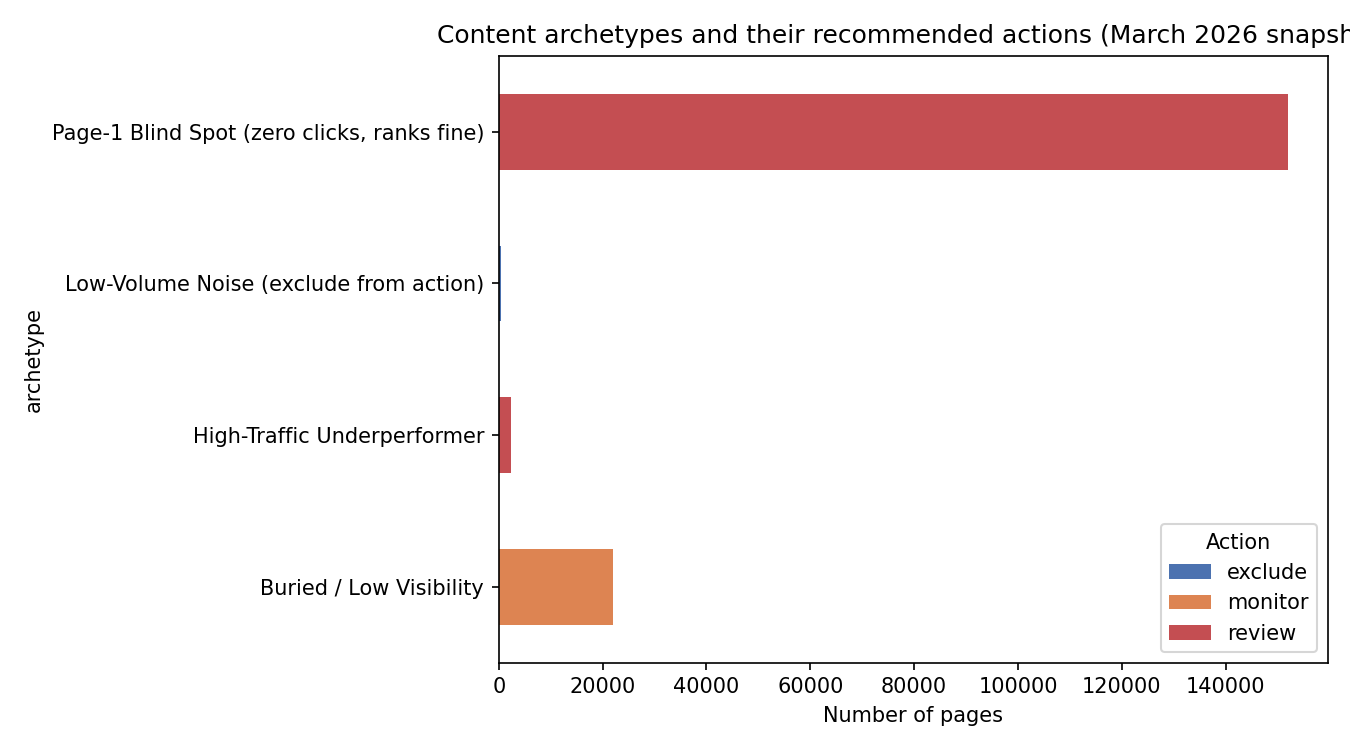

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## 5-Minute Demo Outline (ML-12)

**0:00–0:30 — The question**
"Out of 331,000+ real content pages, which ones should an editor fix first — and what kind of fix?"

**0:30–1:30 — Data & method**
March 2026 snapshot, FlyRank's production search warehouse. K-Means clustering (k=5) on impressions, CTR, position, and page age — grouping pages by behavior, not a single score.

**1:30–3:00 — Show the chart**
[Open archetype_action_breakdown.png] "One archetype — 'Page-1 Blind Spot' — is ~85% of visible pages. These pages rank fine, around position 7, but get essentially zero clicks."

**3:00–4:00 — The honest result**
"The old rule-based baseline only caught about a third of these pages. Clustering catches nearly all of them — and it held up on 17 completely unseen clients (silhouette 0.496), not just the training data."

**4:00–4:30 — The recommendation**
"This becomes a ranked action queue: work Page-1 Blind Spot first, since fixing a title or meta description is a plausible, common fix — then High-Traffic Underperformers."

**4:30–5:00 — Close, honestly**
"One caveat: 57% of the review queue looks individually fine and is only flagged by group behavior — so it's a prioritized list, not a list of confirmed problems. Full paper and code are linked here." [show URL]


## Shareable Cuts (ML-12)

**Social post (methodology-focused):**

Spent the last 8 weeks building a content-performance clustering system on 331,437 real production content pages (real Google Search Console + Analytics data, one month, one client-grouped holdout split to keep it honest).

Instead of one refresh score, I grouped pages into 5 recurring behavior archetypes with K-Means. The standout: ~85% of visible pages rank fine (page 1) but get ~0% clicks — a pattern a simple threshold rule was mostly missing, and one that held up on 17 completely unseen clients, not just the training data.

Full writeup, honest limitations, and code: [paper URL]

**Employer-facing summary (3 sentences):**

I built an unsupervised clustering system that groups 331,000+ real content pages into five recurring search-performance archetypes, using production Google Search Console and Analytics data. Validated with a client-grouped holdout split to prevent leakage, the model surfaced a dominant pattern — pages ranking well but earning almost no clicks — that a prior rule-based system caught in only a third of cases. The output is a ranked, reason-coded action queue that lets a content strategist prioritize thousands of pages in minutes instead of reviewing them one by one.
